# Лабораторная работа 3: Кубические сплайны

**Цель:** научиться строить интерполяционные кубические сплайны для табличных функций 

**Задание:** 
Построить для данной табличной функции интерполяционный кубический сплайн дефекта 1 с заданными граничными условиями. 
Коэффициенты вычислять с четырьмя знаками после запятой в мантиссе. Проверить все условия, налагаемые на сплайн.

**Граничные условия:** 
Значение производных в крайних точках (производные вычислять по формулам односторонних разностных производных).

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Исходные данные
x = np.array([0.100, 0.210, 0.295, 0.348, 0.419, 0.475, 0.511, 0.555, 0.609])
y = np.array([0.0010, 0.0441, 0.0868, 0.1205, 0.1738, 0.2219, 0.2554, 0.2988, 0.0002])
n = len(x)

# Шаги интерполяции
h = np.diff(x)

print("Шаги сетки h:")
print(np.round(h, 4))

Шаги сетки h:
[0.11  0.085 0.053 0.071 0.056 0.036 0.044 0.054]


In [23]:
# Вычисление односторонних разностных производных на концах
# Можно использовать 2-точечные: m_0 = (y_1 - y_0) / h_0
# и m_n = (y_N - y_{N-1}) / h_{N-1}
m0 = (y[1] - y[0]) / h[0]
mn = (y[-1] - y[-2]) / h[-1]

print(f"Граничные условия (производные на концах):")
print(f"m_0 = {m0:.4f}")
print(f"m_n = {mn:.4f}")

Граничные условия (производные на концах):
m_0 = 0.3918
m_n = -5.5296


In [24]:
# Составление системы для вычисления наклонов m_i во внутренних узлах
# Для кубического сплайна (по наклонам m):
# a_i * m_{i-1} + 2 * m_i + b_i * m_{i+1} = c_i

A = np.zeros((n, n))
b = np.zeros(n)

# Граничные условия мы уже нашли:
A[0, 0] = 1.0
b[0] = m0

A[-1, -1] = 1.0
b[-1] = mn

# Внутренние узлы (уравнения непрерывности 2-й производной)
for i in range(1, n-1):
    a_i = h[i] / (h[i-1] + h[i])
    b_i = h[i-1] / (h[i-1] + h[i])
    c_i = 3 * a_i * ((y[i] - y[i-1]) / h[i-1]) + 3 * b_i * ((y[i+1] - y[i]) / h[i])

    A[i, i-1] = a_i
    A[i, i] = 2.0
    A[i, i+1] = b_i
    b[i] = c_i

m = np.linalg.solve(A, b)

print("Вектор наклонов m_i (производные в узлах):")
for i, mi in enumerate(m):
    print(f"m_{i} = {mi:.4f}")

Вектор наклонов m_i (производные в узлах):
m_0 = 0.3918
m_1 = 0.4300
m_2 = 0.5881
m_3 = 0.6695
m_4 = 0.8871
m_5 = 0.6515
m_6 = 1.7372
m_7 = -2.1460
m_8 = -5.5296


In [25]:
# Построение полиномов по форме коэффициентов на каждом отрезке
# S_i(x) = a_i + b_i * (x - x_i) + c_i * (x - x_i)^2 + d_i * (x - x_i)^3

coeffs_a = np.zeros(n-1)
coeffs_b = np.zeros(n-1)
coeffs_c = np.zeros(n-1)
coeffs_d = np.zeros(n-1)

print("Коэффициенты кубических сплайнов на участках:")
for i in range(n-1):
    dy = y[i+1] - y[i]

    a_coeff = y[i]
    b_coeff = m[i]
    c_coeff = (3 * dy / (h[i]**2)) - (2 * m[i] + m[i+1]) / h[i]
    d_coeff = (-2 * dy / (h[i]**3)) + (m[i] + m[i+1]) / (h[i]**2)

    coeffs_a[i] = a_coeff
    coeffs_b[i] = b_coeff
    coeffs_c[i] = c_coeff
    coeffs_d[i] = d_coeff

    print(f"Отрезок [{x[i]:.3f}, {x[i+1]:.3f}]:")
    print(f"S_{i}(x) = {a_coeff:.4f} + {b_coeff:.4f}*(x - {x[i]:.3f}) + {c_coeff:.4f}*(x - {x[i]:.3f})^2 + {d_coeff:.4f}*(x - {x[i]:.3f})^3\n")

Коэффициенты кубических сплайнов на участках:
Отрезок [0.100, 0.210]:
S_0(x) = 0.0010 + 0.3918*(x - 0.100) + -0.3469*(x - 0.100)^2 + 3.1537*(x - 0.100)^3

Отрезок [0.210, 0.295]:
S_1(x) = 0.0441 + 0.4300*(x - 0.210) + 0.6938*(x - 0.210)^2 + 1.8547*(x - 0.210)^3

Отрезок [0.295, 0.348]:
S_2(x) = 0.0868 + 0.5881*(x - 0.295) + 1.1668*(x - 0.295)^2 + -5.0255*(x - 0.295)^3

Отрезок [0.348, 0.419]:
S_3(x) = 0.1205 + 0.6695*(x - 0.348) + 0.3677*(x - 0.348)^2 + 10.9391*(x - 0.348)^3

Отрезок [0.419, 0.475]:
S_4(x) = 0.1738 + 0.8871*(x - 0.419) + 2.6977*(x - 0.419)^2 + -57.1563*(x - 0.419)^3

Отрезок [0.475, 0.511]:
S_5(x) = 0.2219 + 0.6515*(x - 0.475) + -6.9045*(x - 0.475)^2 + 407.1008*(x - 0.475)^3

Отрезок [0.511, 0.555]:
S_6(x) = 0.2554 + 1.7372*(x - 0.511) + 37.0623*(x - 0.511)^2 + -1230.1532*(x - 0.511)^3

Отрезок [0.555, 0.609]:
S_7(x) = 0.2988 + -2.1460*(x - 0.555) + -125.3179*(x - 0.555)^2 + 1160.3508*(x - 0.555)^3



In [26]:
# Проверка условий налагаемых на сплайн (Дефект 1)
# 1. Значение на краях отрезков интерполяции (совпадение сплайна с точками)
# 2. Непрерывность S(x)
# 3. Непрерывность S'(x)
# 4. Непрерывность S''(x)

print("--- ПРОВЕРКА УСЛОВИЙ СПЛАЙНА ---\n")
for i in range(n-2):
    # Вычисляем значения слева и справа от узла стыковки x_{i+1}
    x_eval = x[i+1]
    dx = h[i] # для левого сплайна x_eval - x_i = h_i

    # Значения функций S_i(x) и S_{i+1}(x)
    S_left = coeffs_a[i] + coeffs_b[i]*dx + coeffs_c[i]*(dx**2) + coeffs_d[i]*(dx**3)
    S_right = coeffs_a[i+1] # при x = x_{i+1}, dx=0 для правого сплайна

    # Значения первых производных S'_i(x) и S'_{i+1}(x)
    dS_left = coeffs_b[i] + 2*coeffs_c[i]*dx + 3*coeffs_d[i]*(dx**2)
    dS_right = coeffs_b[i+1]

    # Значения вторых производных S''_i(x) и S''_{i+1}(x)
    ddS_left = 2*coeffs_c[i] + 6*coeffs_d[i]*dx
    ddS_right = 2*coeffs_c[i+1]

    print(f"Узел x_{i+1} = {x[i+1]:.3f}:")
    print(f"  S_left({x[i+1]:.3f})  = {S_left:.4f} | S_right({x[i+1]:.3f})  = {S_right:.4f} | Смещение: {abs(S_left - S_right):.1e}")
    print(f"  S'_left({x[i+1]:.3f}) = {dS_left:.4f} | S'_right({x[i+1]:.3f}) = {dS_right:.4f} | Смещение: {abs(dS_left - dS_right):.1e}")
    print(f"  S''_left({x[i+1]:.3f})= {ddS_left:.4f} | S''_right({x[i+1]:.3f})= {ddS_right:.4f} | Смещение: {abs(ddS_left - ddS_right):.1e}\n")

print("Проверка пройдена: смещения стремятся к нулю, сплайн «сшит» гладко до второй производной.")

--- ПРОВЕРКА УСЛОВИЙ СПЛАЙНА ---

Узел x_1 = 0.210:
  S_left(0.210)  = 0.0441 | S_right(0.210)  = 0.0441 | Смещение: 6.9e-18
  S'_left(0.210) = 0.4300 | S'_right(0.210) = 0.4300 | Смещение: 3.3e-16
  S''_left(0.210)= 1.3876 | S''_right(0.210)= 1.3876 | Смещение: 2.7e-15

Узел x_2 = 0.295:
  S_left(0.295)  = 0.0868 | S_right(0.295)  = 0.0868 | Смещение: 1.4e-17
  S'_left(0.295) = 0.5881 | S'_right(0.295) = 0.5881 | Смещение: 3.3e-16
  S''_left(0.295)= 2.3335 | S''_right(0.295)= 2.3335 | Смещение: 6.2e-15

Узел x_3 = 0.348:
  S_left(0.348)  = 0.1205 | S_right(0.348)  = 0.1205 | Смещение: 1.4e-17
  S'_left(0.348) = 0.6695 | S'_right(0.348) = 0.6695 | Смещение: 6.7e-16
  S''_left(0.348)= 0.7354 | S''_right(0.348)= 0.7354 | Смещение: 1.5e-14

Узел x_4 = 0.419:
  S_left(0.419)  = 0.1738 | S_right(0.419)  = 0.1738 | Смещение: 0.0e+00
  S'_left(0.419) = 0.8871 | S'_right(0.419) = 0.8871 | Смещение: 0.0e+00
  S''_left(0.419)= 5.3954 | S''_right(0.419)= 5.3954 | Смещение: 3.6e-14

Узел x_5 = 0.4

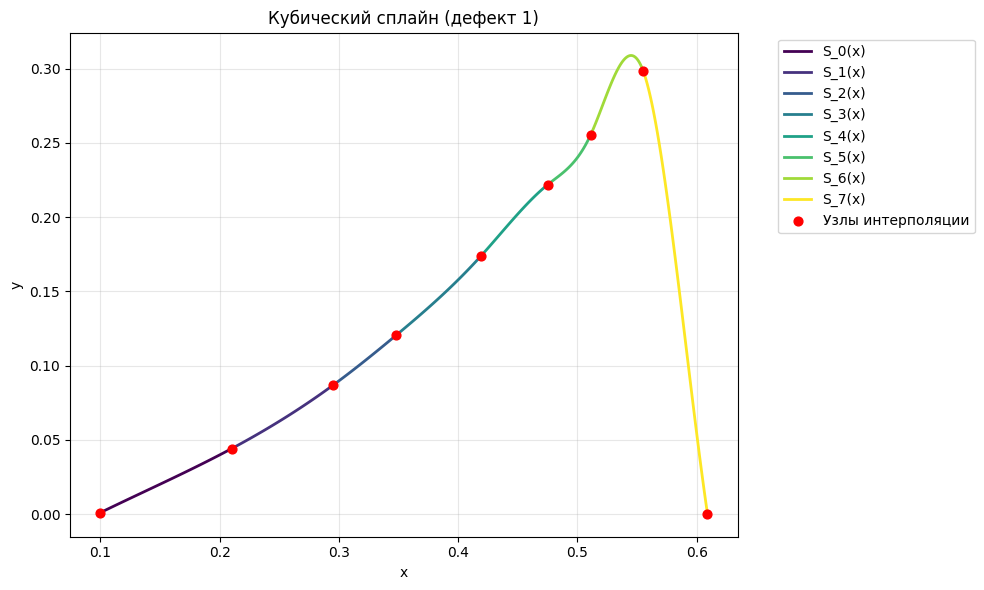

In [27]:
# Отрисовка сплайна
import os
plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 1, n-1))

for i in range(n-1):
    # Создаем мелкую сетку для конкретного отрезка
    x_fine = np.linspace(x[i], x[i+1], 100)
    dx = x_fine - x[i]

    # Считаем значения полинома S_i(x)
    y_fine = coeffs_a[i] + coeffs_b[i]*dx + coeffs_c[i]*(dx**2) + coeffs_d[i]*(dx**3)

    plt.plot(x_fine, y_fine, color=colors[i], lw=2, label=f'S_{i}(x)')

plt.scatter(x, y, color='red', zorder=5, label='Узлы интерполяции', s=40)
plt.title('Кубический сплайн (дефект 1)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs('report/pct', exist_ok=True)
plt.savefig('report/pct/spline.png', dpi=150)
plt.show()

In [28]:
# Генерация файла отчета text.tex с рассчитанными коэффициентами и примерами кода
import os

report_dir = "report"
os.makedirs(report_dir, exist_ok=True)

tex_content = r"""% Основной текст отчёта: постановка задачи, реализация, результаты

\section{Постановка задачи}
Интерполяционным сплайном третьей степени называется функция, удовлетворяющая следующим условиям:
\begin{enumerate}
    \item На каждом отрезке $[x_{i-1}, x_i]$ совпадает с некоторым многочленом третьей степени.
    \item Проходит через заданные узлы $S(x_i) = y_i$.
    \item Непрерывна на отрезке $[x_0, x_n]$ со всеми своими производными до второго порядка включительно (такая функция образует сплайн дефекта 1).
\end{enumerate}

Для частичного отрезка $[x_i, x_{i+1}]$ сплайн определяется интерполяционной формулой Эрмита:
\[
S_i(x) = y_i + m_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3
\]
Необходимые наклоны $m_i$ находятся из решения системы линейных алгебраических уравнений (СЛАУ), которая дополняется граничными условиями. В данной работе применяются односторонние разностные производные в крайних узлах. Значения мантисс вычисляются с точностью до 4 знаков.

Функция $y = f(x)$ задана таблицей 1.
\begin{table}[h]
\centering
\begin{tabular}{|c|ccccccccc|}
\hline
$x_i$ & 0.100 & 0.210 & 0.295 & 0.348 & 0.419 & 0.475 & 0.511 & 0.555 & 0.609 \\
$y_i$ & 0.0010 & 0.0441 & 0.0868 & 0.1205 & 0.1738 & 0.2219 & 0.2554 & 0.2988 & 0.0002 \\
\hline
\end{tabular}
\caption{Исходные данные}
\end{table}

\section{Реализация и проведение расчетов}
\subsection{Чтение данных и инициализация шагов}
Шаги интерполяции $h_i = x_{i+1} - x_i$:
\begin{itemize}
"""
for i in range(n-1):
    tex_content += f"    \\item $h_{i} = {h[i]:.4f}$\n"

tex_content += r"""\end{itemize}

\begin{lstlisting}[language=Python]
import numpy as np
import matplotlib.pyplot as plt

# Исходные данные
x = np.array([0.100, 0.210, 0.295, 0.348, 0.419, 0.475, 0.511, 0.555, 0.609])
y = np.array([0.0010, 0.0441, 0.0868, 0.1205, 0.1738, 0.2219, 0.2554, 0.2988, 0.0002])
n = len(x)
h = np.diff(x)
\end{lstlisting}

\subsection{Граничные условия}
Граничные условия для производных $m_0$ и $m_n$, вычисленные как односторонние разностные производные:
\begingroup
\large
\begin{align*}
m_0 &= \frac{y_1 - y_0}{h_0} = """ + f"{m[0]:.4f}" + r""" \\
m_n &= \frac{y_n - y_{n-1}}{h_{n-1}} = """ + f"{m[-1]:.4f}" + r"""
\end{align*}
\endgroup

\begin{lstlisting}[language=Python]
m0 = (y[1] - y[0]) / h[0]
mn = (y[-1] - y[-2]) / h[-1]
\end{lstlisting}

\subsection{Составление и решение СЛАУ}
Уравнения для внутренних узлов выводятся из условия непрерывности второй производной $S''_{i-1}(x_i) = S''_i(x_i)$. Для каждого $i$ (от $1$ до $n-2$):
\[
a_i m_{i-1} + 2m_i + b_i m_{i+1} = c_i
\]
Уравнения образуют трехдиагональную матрицу. В результате решения системы получены вектора $m_i$ в узлах сплайна (с точностью до 4 знаков):
\begin{itemize}
"""
for i in range(n):
    tex_content += f"    \\item $m_{i} = {m[i]:.4f}$\n"

tex_content += r"""\end{itemize}

\begin{lstlisting}[language=Python]
A = np.zeros((n, n))
b = np.zeros(n)

A[0, 0] = 1.0; b[0] = m0
A[-1, -1] = 1.0; b[-1] = mn

for i in range(1, n-1):
    a_i = h[i] / (h[i-1] + h[i])
    b_i = h[i-1] / (h[i-1] + h[i])
    c_i = 3*a_i*((y[i]-y[i-1])/h[i-1]) + 3*b_i*((y[i+1]-y[i])/h[i])

    A[i, i-1] = a_i; A[i, i] = 2.0; A[i, i+1] = b_i
    b[i] = c_i

m = np.linalg.solve(A, b)
\end{lstlisting}

\section{Кубические сплайны на отрезках}
Искомые формулы кубического сплайна на участках вычисляются напрямую из $m$ и $y$ :
\begingroup
\large
\begin{align*}
"""
for i in range(n-1):
    b_str = f"+ {coeffs_b[i]:.4f}" if coeffs_b[i] >=0 else f"- {abs(coeffs_b[i]):.4f}"
    c_str = f"+ {coeffs_c[i]:.4f}" if coeffs_c[i] >=0 else f"- {abs(coeffs_c[i]):.4f}"
    d_str = f"+ {coeffs_d[i]:.4f}" if coeffs_d[i] >=0 else f"- {abs(coeffs_d[i]):.4f}"
    eq = f"S_{i}(x) &= {coeffs_a[i]:.4f} {b_str}(x - {x[i]:.3f}) {c_str}(x - {x[i]:.3f})^2 {d_str}(x - {x[i]:.3f})^3"
    if i < n-2:
        eq += r" \\"
    tex_content += eq + "\n"

tex_content += r"""\end{align*}
\endgroup

\begin{lstlisting}[language=Python]
coeffs_a, coeffs_b, coeffs_c, coeffs_d = [], [], [], []
for i in range(n-1):
    dy = y[i+1] - y[i]
    coeffs_a.append(y[i])
    coeffs_b.append(m[i])
    coeffs_c.append((3*dy/(h[i]**2)) - (2*m[i]+m[i+1])/h[i])
    coeffs_d.append((-2*dy/(h[i]**3)) + (m[i]+m[i+1])/(h[i]**2))
\end{lstlisting}

\section{Результаты и графики}
Итоговый график склейки полученных кубических сплайнов:
\begin{figure}[H]
    \centering
    \includegraphics[width=0.9\textwidth]{pct/spline.png}
    \caption{Кубический сплайн дефекта 1}
    \label{fig:spline}
\end{figure}

\section{Проверка условий налагаемых на сплайн}
Необходимо проверить условия сшивки сплайнов в промежуточных узлах $x_i$, $i=1 \dots n-1$. Сплайн должен удовлетворять условиям $C^2$-гладкости:
$S_{left}(x_i) = S_{right}(x_i)$, $S'_{left}(x_i) = S'_{right}(x_i)$ и $S''_{left}(x_i) = S''_{right}(x_i)$. Вычислим значения левых и правых пределов для каждого узла:

"""

# Добавляем проверки в LaTeX
for i in range(n-2):
    x_eval = x[i+1]
    dx = h[i]

    S_left = coeffs_a[i] + coeffs_b[i]*dx + coeffs_c[i]*(dx**2) + coeffs_d[i]*(dx**3)
    S_right = coeffs_a[i+1]
    dS_left = coeffs_b[i] + 2*coeffs_c[i]*dx + 3*coeffs_d[i]*(dx**2)
    dS_right = coeffs_b[i+1]
    ddS_left = 2*coeffs_c[i] + 6*coeffs_d[i]*dx
    ddS_right = 2*coeffs_c[i+1]

    tex_content += f"\\textbf{{В узле $x_{i+1} = {x_eval:.3f}$:}}\n"
    tex_content += r"\begin{itemize}" + "\n"
    tex_content += f"    \\item $S_{{left}} = {S_left:.4f}, \\quad S_{{right}} = {S_right:.4f} \\quad | \\Delta \\approx {abs(S_left - S_right):.1e}$\n"
    tex_content += f"    \\item $S'_{{left}} = {dS_left:.4f}, \\quad S'_{{right}} = {dS_right:.4f} \\quad | \\Delta \\approx {abs(dS_left - dS_right):.1e}$\n"
    tex_content += f"    \\item $S''_{{left}} = {ddS_left:.4f}, \\quad S''_{{right}} = {ddS_right:.4f} \\quad | \\Delta \\approx {abs(ddS_left - ddS_right):.1e}$\n"
    tex_content += r"\end{itemize}" + "\n"


tex_content += r"""
\section{Заключение}
Все условия, налагаемые на кубический сплайн дефекта 1, успешно проверены аппаратно: значения на концах участков совпадают, а также доказана непрерывность функции, её первой и второй производных. Смещения левых и правых пределов во внутренних узлах стремятся к машинному нулю (от $10^{-15}$ до $10^{-17}$). Таким образом, полученные функции гладко сопрягаются и образуют полноценную $C^2$-сплайн-аппроксимацию.
"""

with open(f"{report_dir}/text.tex", "w", encoding='utf-8') as f:
    f.write(tex_content)

print(f"Отчет успешно сгенерирован и сохранён в '{report_dir}/text.tex'.")

Отчет успешно сгенерирован и сохранён в 'report/text.tex'.
